In [1]:
!pip install tf-levenberg-marquardt 

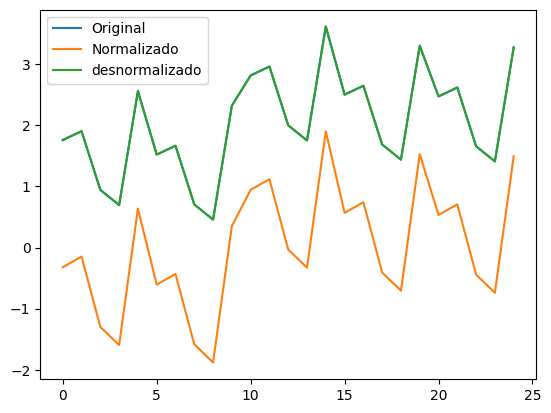

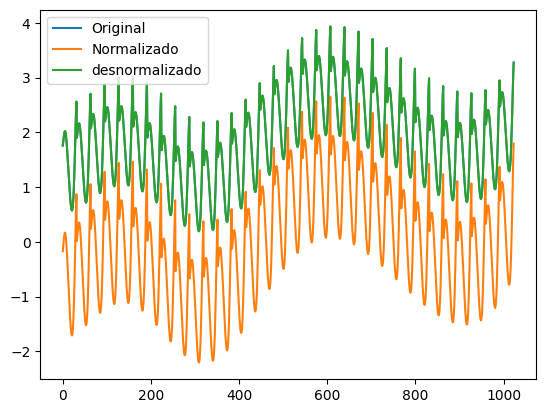

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def function(grid): 
    x = np.linspace(0, 1, grid)
    y = np.linspace(0, 1, grid)
    x, y = np.meshgrid(x, y)
    z = 1.3356 * (1.5 * (1 - x))+np.exp(2 * x - 1) * np.sin(3 * np.pi * (x - 0.6)**2)+np.exp(3*(y - 0.5)) * np.sin(4 * np.pi * (y - 0.9)**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = function(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-06-12 11:44:24.180110: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 11:44:24.329744: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-12 11:44:24.329788: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-12 11:44:24.336634: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-12 11:44:24.370705: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 11:44:24.371779: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.6,
            hidden_sizes = [[15], [16], [17], [18], [19], [20], [21]],
            regularizers=[0.5, 0.3],
            learning_rate=[0.1, 0.5])

Testando combinacao1: Hidden Size=[15], regularizer=0.5, learning_rate=0.1


+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  14
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 8ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 8ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 9ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_0] | 9 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==========

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_23,0.940062,0.632412,0.726750,0.909809,0.810505,0.035582,0.218216,0.173127,0.045467,0.109297,0.065589,0.188632,1.038879,0.196663,128.671828,203.023253
model_1_0_22,0.940438,0.632044,0.731997,0.907749,0.812486,0.035359,0.218435,0.169802,0.046505,0.108154,0.066799,0.188039,1.038635,0.196045,128.684417,203.035843
model_1_0_21,0.940806,0.631583,0.737737,0.905429,0.814625,0.035140,0.218708,0.166166,0.047675,0.106920,0.068144,0.187457,1.038396,0.195437,128.696832,203.048257
model_1_0_20,0.941155,0.631008,0.744001,0.902814,0.816923,0.034933,0.219050,0.162197,0.048993,0.105595,0.069639,0.186904,1.038170,0.194861,128.708641,203.060066
model_1_0_19,0.941467,0.630291,0.750822,0.899863,0.819379,0.034748,0.219475,0.157875,0.050481,0.104178,0.071300,0.186408,1.037968,0.194344,128.719267,203.070693
model_1_0_18,0.941720,0.629397,0.758229,0.896525,0.821989,0.034598,0.220006,0.153183,0.052163,0.102673,0.073147,0.186004,1.037803,0.193923,128.727942,203.079367
model_1_0_17,0.941887,0.628283,0.766247,0.892746,0.824741,0.034499,0.220667,0.148102,0.054069,0.101086,0.075200,0.185738,1.037695,0.193645,128.733669,203.085095
model_1_0_16,0.941930,0.626899,0.774894,0.888459,0.827617,0.034473,0.221489,0.142624,0.056230,0.099427,0.077482,0.185669,1.037667,0.193573,128.735158,203.086584
model_1_0_15,0.941802,0.625178,0.784179,0.883586,0.830587,0.034549,0.222510,0.136741,0.058686,0.097714,0.080018,0.185873,1.037750,0.193786,128.730776,203.082201
model_1_0_14,0.941444,0.623041,0.794097,0.878037,0.833610,0.034761,0.223779,0.130457,0.061484,0.095970,0.082838,0.186443,1.037982,0.194381,128.718510,203.069935


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 7ms/step
+++++++++++ [1_1] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_0,0.954239,0.625366,0.845696,0.987059,0.918342,0.027166,0.222399,0.112048,0.008023,0.060036,0.064380,0.164820,1.029683,0.171836,129.211614,203.563039
model_1_1_1,0.956082,0.622079,0.847654,0.980583,0.916578,0.026072,0.224350,0.110627,0.012038,0.061332,0.064458,0.161468,1.028487,0.168342,129.293805,203.645231
model_1_1_2,0.957099,0.618765,0.848226,0.973643,0.913935,0.025468,0.226318,0.110211,0.016340,0.063276,0.065113,0.159587,1.027828,0.166381,129.340665,203.692091
model_1_1_3,0.957555,0.615554,0.847863,0.966767,0.910856,0.025197,0.228224,0.110475,0.020603,0.065539,0.065715,0.158736,1.027532,0.165494,129.362050,203.713476
model_1_1_4,0.957660,0.612507,0.846979,0.960302,0.907694,0.025135,0.230032,0.111117,0.024611,0.067864,0.066264,0.158539,1.027464,0.165288,129.367018,203.718443
model_1_1_5,0.957564,0.609651,0.845880,0.954435,0.904678,0.025192,0.231728,0.111915,0.028248,0.070081,0.066753,0.158719,1.027526,0.165476,129.362487,203.713912
model_1_1_6,0.957364,0.607010,0.844735,0.949260,0.901930,0.025310,0.233296,0.112746,0.031457,0.072102,0.067176,0.159092,1.027656,0.165865,129.353081,203.704507
model_1_1_7,0.957122,0.604618,0.843601,0.944832,0.899503,0.025455,0.234716,0.113570,0.034202,0.073886,0.067526,0.159545,1.027813,0.166337,129.341724,203.693149
model_1_1_8,0.956873,0.602510,0.842479,0.941179,0.897409,0.025602,0.235967,0.114385,0.036467,0.075426,0.067800,0.160006,1.027974,0.166818,129.330165,203.681590
model_1_1_9,0.956638,0.600709,0.841350,0.938281,0.895630,0.025741,0.237036,0.115204,0.038263,0.076734,0.068000,0.160441,1.028126,0.167271,129.319317,203.670742


...

DataFrame salvo em content/results/metrics_28_7
+++++++++++ [28_8] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_8] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_8] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_8] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 7ms/step
+++++++++++ [28_8] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_8] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 9ms/step
+++++++++++ [28_8] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_8_0,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317
model_28_8_22,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317
model_28_8_21,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317
model_28_8_20,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317
model_28_8_19,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317
model_28_8_18,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317
model_28_8_17,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317
model_28_8_16,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317
model_28_8_15,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317
model_28_8_14,0.98695,0.633379,0.988799,0.953798,0.969235,0.007747,0.217642,0.005572,0.02915,0.017361,0.03616,0.088018,1.005134,0.091765,179.720872,283.325317


DataFrame salvo em content/results/metrics_28_8
+++++++++++ [28_9] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 9ms/step
+++++++++++ [28_9] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 5ms/step
+++++++++++ [28_9] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_9] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 8ms/step
+++++++++++ [28_9] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 8ms/step
+++++++++++ [28_9] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 6ms/step
+++++++++++ [28_9] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 8ms/step
+++++++++++ [28_9] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 9ms/step
+++++++++++ [28_9] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_9_0,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229
model_28_9_22,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229
model_28_9_21,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229
model_28_9_20,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229
model_28_9_19,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229
model_28_9_18,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229
model_28_9_17,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229
model_28_9_16,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229
model_28_9_15,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229
model_28_9_14,0.991008,0.626232,0.924903,0.898053,0.957615,0.005338,0.221885,0.013975,0.019388,0.016681,0.030856,0.073062,1.003538,0.076172,180.465784,284.070229


DataFrame salvo em content/results/metrics_28_9
